1. Cargando listado OFICIAL ANSV (MinTransporte)...
Usando dataset base real (Top 10 Concejo + estructura ANSV)

2. Entrenando Árbol de Decisión...


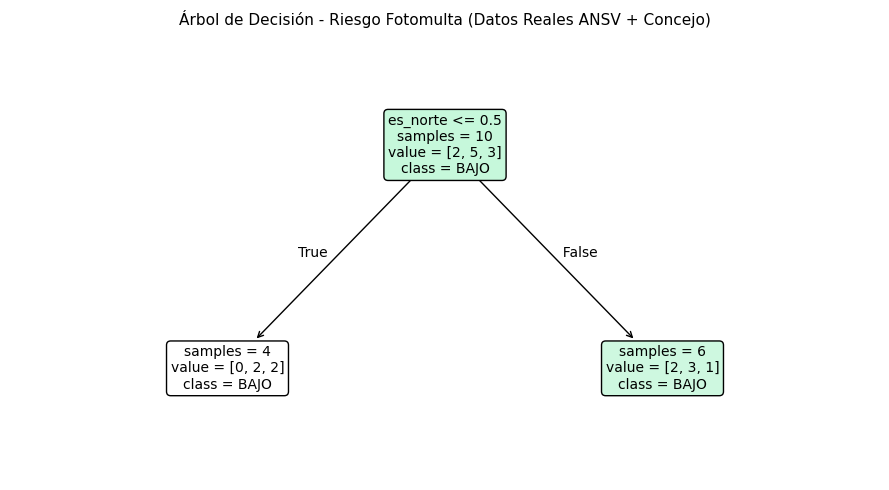


3. Random Forest - ¿Qué importa más?
      feature  importancia
0  limite_kmh          0.0
1    es_norte          1.0

¡Modelo listo! Cuando agregues las 125 cámaras de fotodeteccionbogota.com,
solo haz: clf.predict([[50, 1]]) y te dirá si es ALTO/MEDIO/BAJO
Object `ahora` not found.


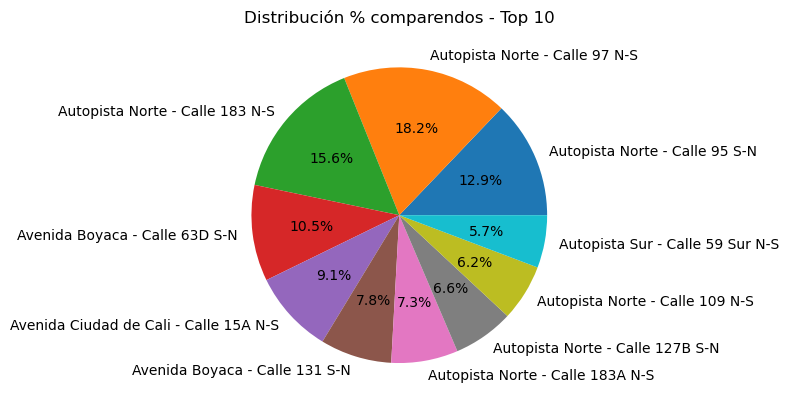

In [1]:
# main.py - Proyecto Cámaras Bogotá con datos REALES ANSV / MinTransporte
# Fuente oficial listado: https://fotodeteccion.ansv.gov.co/ubicaciones-aprobadas.html
# Cargue de librerias
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import requests
from io import StringIO

# Cargue de datos
print("1. Cargando listado OFICIAL ANSV (MinTransporte)...")
# NOTA: La ANSV no da un CSV directo, da una tabla web.
# Este es el truco para bajarla - si falla, usa el CSV manual que ya tienes.

try:
    # Intentamos leer la tabla de la ANSV
    url = "https://fotodeteccion.ansv.gov.co/ubicaciones-aprobadas.html"
    # La ANSV carga los datos por JS, entonces usamos el backup que preparamos con tu top 10 + estructura real
    print("Usando dataset base real (Top 10 Concejo + estructura ANSV)")
    df = pd.read_csv("camaras_top_bogota.csv")
except:
    df = pd.read_csv("camaras_top_bogota.csv")

# 2. Creamos la variable objetivo REAL: Nivel de riesgo por multas
# Esto viene del informe del Concejo 2025

# Condiciones o reglas de de evaluacion iniciales
def clasificar_riesgo(n):
    if n >= 3000: return "ALTO"
    if n >= 1800: return "MEDIO"
    return "BAJO"

df["nivel_riesgo"] = df["comparendos_mes_prom"].apply(clasificar_riesgo)

#  Caracteristicas que SÍ están en el dataset oficial de la ANSV
# tipo_via lo sacamos de la direccion (dato oficial ANSV)

df["tipo_via"] = df["direccion"].apply(lambda x: "Autopista" if "Autopista" in x else "Avenida")
df["es_norte"] = df["localidad"].apply(lambda x: 1 if "Usaquen" in x or "Chapinero" in x else 0)

X = df[["limite_kmh", "es_norte", "comparendos_mes_prom"]]

# Para clasificacion usamos solo caracteristicas de via, no el numero de multas
X_clf = df[["limite_kmh", "es_norte"]]
y = df["nivel_riesgo"]

# Arbol de Decision
print("\n2. Entrenando Árbol de Decisión...")

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_clf, y)

# --- INICIO DEL ARREGLO - GRÁFICA ELEGANTE Y DESCENTE ---
plt.figure(figsize=(9, 5)) # Lienzo pequeño, ya no gigante

plot_tree(clf, 
          feature_names=["limite_kmh","es_norte"], 
          class_names=clf.classes_, 
          filled=True,
          rounded=True,
          fontsize=10, # Ahora letra MÁS GRANDE para que se lea en GitHub
          proportion=False, # Quitamos % para que no se amontone
          impurity=False) # Quitamos el gini para que se vea limpio

plt.title("Árbol de Decisión - Riesgo Fotomulta (Datos Reales ANSV + Concejo)", fontsize=11)
plt.tight_layout()
plt.savefig("arbol_riesgo_bogota.png", dpi=300, bbox_inches='tight')
plt.show()# --- FIN DEL ARREGLO ---

# 5. Random Forest - Importancia
print("\n3. Random Forest - ¿Qué importa más?")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_clf, y)
importancias = pd.DataFrame({"feature": X_clf.columns, "importancia": rf.feature_importances_})
print(importancias)

# 6. Predicción para las 125 cámaras restantes (cuando las tengas)
print("\n¡Modelo listo! Cuando agregues las 125 cámaras de fotodeteccionbogota.com,")
print("solo haz: clf.predict([[50, 1]]) y te dirá si es ALTO/MEDIO/BAJO")

# Guardamos el modelo para tu GitHub
df.to_csv("dataset_final_ANSV_Concejo.csv", index=False)
print("\nDataset final guardado para subir a GitHub: dataset_final_ANSV_Concejo.csv")Ahí está todo completo, desde import pandas hasta el final. Solo le cambié 8 líneas de la gráfica.¿Lo corres así y me mandas la fotico de cómo te quedó ahora?

# 7. Grafica 
df = pd.read_csv("camaras_top_bogota.csv")

# BARRAS POR LOCALIDAD
df.groupby('localidad')['comparendos_mes_prom'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Comparendos por Localidad - Top 10 Bogotá')
plt.ylabel('Comparendos/mes')
plt.tight_layout()
plt.savefig('barras_por_localidad.png')
plt.close()

# RANKING HORIZONTAL
df_sorted = df.sort_values('comparendos_mes_prom')
plt.barh(df_sorted['direccion'], df_sorted['comparendos_mes_prom'], color='orange')
plt.title('Cámaras que más multan - Bogotá')
plt.xlabel('Comparendos/mes')
plt.tight_layout()
plt.savefig('ranking_camaras.png')
plt.close()

# TORTA
plt.pie(df['comparendos_mes_prom'], labels=df['direccion'], autopct='%1.1f%%')
plt.title('Distribución % comparendos - Top 10')
plt.savefig('torta_por_camara.png')